# Step 6: Metrics & Outputs

This notebook loads a completed simulation run and produces:
- Screening volume and eligibility summaries
- Cervical result distribution (overall and by age stratum)
- Colposcopy completion and CIN grade breakdown
- Loss-to-follow-up rates at each decision node
- Treatment outcomes
- Workflow comparison: fragmented vs. coordinated (when implemented)

Run `04_simulation_runner.ipynb` first, or call `run_simulation()` in the cell below.

In [ ]:
import sys, random
sys.path.insert(0, '../src')

import config as cfg
from metrics import initialize_metrics, compute_rates, print_summary, print_patient_trace

print('Imports OK')

## Run Simulation (or load from runner)

If you already ran `04_simulation_runner.ipynb` in the same kernel,
comment out the `%run` line and use the existing `state, metrics` variables.

In [2]:
# Option A: run everything fresh
%run "04_simulation_runner.ipynb"
state, metrics = run_simulation(sim_days=365 * 3, seed=42)   # 3-year run
print(f"Simulation complete. Patients in state: {state['patients_created']:,}")

Core imports OK

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ARRIVAL / ACCESS SUMMARY
Total patients created:               3000

Created by type:
  outpatient:                         2082
  drop_in:                            918

Created by destination:
  pcp:                                1088
  gynecologist:                       692
  specialist:                         629
  er:                                 591

Seen by destination:
  pcp:                                600
  gynecologist:                       450
  specialist:                         300
  er:                                 375

Drop-ins converted to outpatients:    694
Critical ER returned next day:        1035
Noncritical ER scheduled outpatient:  792

Outpatient showups:                   8040
Outpatient no-shows:                  0

DAY 0
--------------------------------------------------
--- DAY 0 START ---
Patient 1 arrives as outpati

KeyError: 'patients_created'

KeyError: 'patients_created'

## Full Summary Report

In [3]:
print_summary(metrics)

ARRIVAL / ACCESS SUMMARY


KeyError: 'patients_created'

## Key Rate Table

In [4]:
rates = compute_rates(metrics)

print('Key simulation rates:')
print('-' * 55)
labels = {
    'screening_rate_cervical_pct':  'Cervical screening rate',
    'unscreened_pct':               'Unscreened rate',
    'reschedule_rate_pct':          'Reschedule rate (of unscreened)',
    'abnormal_rate_cervical_pct':   'Cervical abnormal rate',
    'colposcopy_completion_pct':    'Colposcopy completion (of abnormals)',
    'treatment_completion_pct':     'Treatment completion (of colposcopies)',
    'ltfu_rate_pct':                'Overall LTFU rate',
}
for key, label in labels.items():
    print(f'  {label:<40} {rates[key]:6.1f}%')

Key simulation rates:
-------------------------------------------------------
  Cervical screening rate                    79.8%
  Unscreened rate                             0.4%
  Reschedule rate (of unscreened)            50.5%
  Cervical abnormal rate                     12.2%
  Colposcopy completion (of abnormals)       66.1%
  Treatment completion (of colposcopies)    133.6%
  Overall LTFU rate                           7.4%


## Cervical Results by Age Stratum

In [5]:
for stratum in ('young', 'middle', 'older'):
    sub = metrics['cervical_by_age_stratum'].get(stratum, {})
    if not sub:
        continue
    total = sum(sub.values())
    print(f'\nStratum: {stratum}  (n={total:,})')
    for result in ['NORMAL','ASCUS','LSIL','ASC-H','HSIL','HPV_POS_NORMAL_CYTO']:
        cnt = sub.get(result, 0)
        print(f'  {result:<30} {cnt:>6,}  ({100*cnt/max(total,1):.1f}%)')


Stratum: young  (n=4,196)
  NORMAL                          3,634  (86.6%)
  ASCUS                             198  (4.7%)
  LSIL                              201  (4.8%)
  ASC-H                              78  (1.9%)
  HSIL                               36  (0.9%)
  HPV_POS_NORMAL_CYTO                49  (1.2%)

Stratum: middle  (n=14,541)
  NORMAL                         12,821  (88.2%)
  ASCUS                             287  (2.0%)
  LSIL                              215  (1.5%)
  ASC-H                             132  (0.9%)
  HSIL                               90  (0.6%)
  HPV_POS_NORMAL_CYTO               996  (6.8%)


## LTFU Funnel

Shows where patients exit the pathway — useful for identifying the largest drop-off points.

In [6]:
n = max(metrics['n_patients'], 1)

funnel = [
    ('Patients seen by provider',       metrics['n_patients']),
    ('Eligible for ≥1 screening',       metrics['n_eligible_any']),
    ('Cervical screenings completed',   metrics['n_screened']['cervical']),
    ('Abnormal cervical results',       sum(
        v for k, v in metrics['cervical_results'].items() if k != 'NORMAL'
    )),
    ('Colposcopies completed',          metrics['n_colposcopy']),
    ('Excisional treatments (LEEP/cone)', metrics['n_treatment'].get('leep', 0)
                                         + metrics['n_treatment'].get('cone_biopsy', 0)),
]

print('Pathway funnel:')
print('-' * 55)
prev = None
for label, count in funnel:
    drop = f'  (↓ {100*(1-count/prev):.0f}% drop)' if prev and prev > 0 else ''
    print(f'  {label:<42} {count:>6,}{drop}')
    prev = max(count, 1)

Pathway funnel:
-------------------------------------------------------
  Patients seen by provider                  23,490
  Eligible for ≥1 screening                  23,393  (↓ 0% drop)
  Cervical screenings completed              18,737  (↓ 20% drop)
  Abnormal cervical results                   2,282  (↓ 88% drop)
  Colposcopies completed                      1,509  (↓ 34% drop)
  Excisional treatments (LEEP/cone)             375  (↓ 75% drop)


## Workflow Scenario Comparison

Toggle `cfg.WORKFLOW_MODE` to compare fragmented vs. coordinated care.
Capacities and drop-off rates should differ between scenarios.

In [7]:
results_by_mode = {}

for mode in ('fragmented', 'coordinated'):
    cfg.WORKFLOW_MODE = mode
    # TODO: adjust LTFU_PROBS and CAPACITIES for coordinated mode once
    # clinical team provides coordinated-care assumptions
    _, m = run_simulation(sim_days=365, seed=42)
    results_by_mode[mode] = compute_rates(m)

print(f'{"Metric":<42}  {"Fragmented":>14}  {"Coordinated":>14}')
print('-' * 75)
for key, label in labels.items():
    f_val = results_by_mode['fragmented'][key]
    c_val = results_by_mode['coordinated'][key]
    print(f'  {label:<40}  {f_val:>12.1f}%  {c_val:>12.1f}%')

# Reset to default
cfg.WORKFLOW_MODE = 'fragmented'

Metric                                          Fragmented     Coordinated
---------------------------------------------------------------------------
  Cervical screening rate                           79.8%          79.8%
  Unscreened rate                                    0.4%           0.4%
  Reschedule rate (of unscreened)                   50.5%          50.5%
  Cervical abnormal rate                            12.2%          12.2%
  Colposcopy completion (of abnormals)              66.1%          66.1%
  Treatment completion (of colposcopies)           133.6%         133.6%
  Overall LTFU rate                                  7.4%           7.4%


## Plot Placeholder

Add visualisations here once `matplotlib` / `seaborn` is confirmed in the environment.

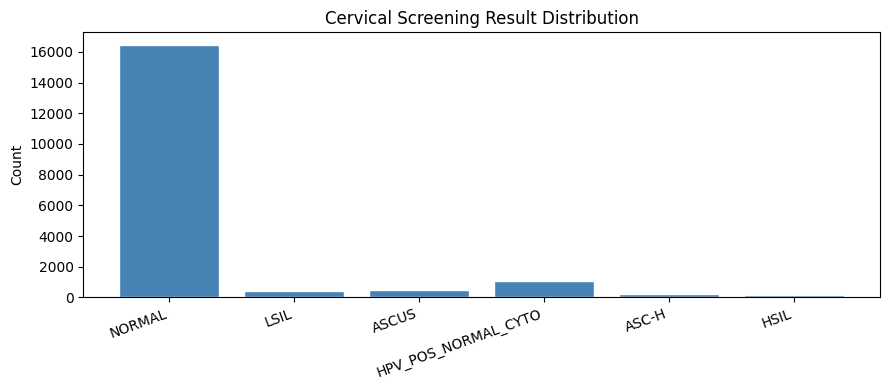

In [8]:
# ── Cervical result bar chart ─────────────────────────────────────────────────
try:
    import matplotlib.pyplot as plt

    cats   = list(metrics['cervical_results'].keys())
    counts = [metrics['cervical_results'][c] for c in cats]

    plt.figure(figsize=(9, 4))
    plt.bar(cats, counts, color='steelblue', edgecolor='white')
    plt.title('Cervical Screening Result Distribution')
    plt.ylabel('Count')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

except ImportError:
    print('matplotlib not available — install with: pip install matplotlib')